Shape of smoke volume['raw']: (125, 1250, 1250)


Text(0.5, 1.0, 'MIP of the masked raw data for neuron_id 20474')

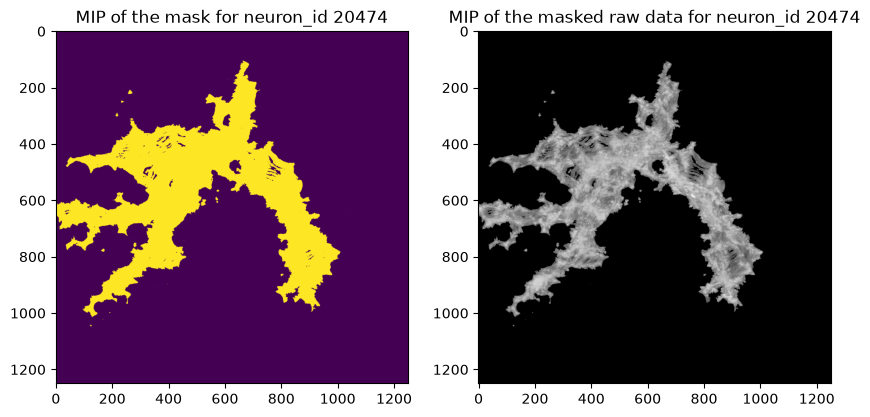

In [1]:
import h5py as h5
vol = h5.File('../data/smoke_data/sample_A_20160501.hdf', 'r')
vol.keys()
images = vol['volumes']
segments = vol['annotations']
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
print('Shape of smoke volume[\'raw\']:', images['raw'].shape)
neuron_ids = np.array(images['labels']['neuron_ids'])  # copy, so this doesn't mutate images[...] in place
mask = neuron_ids == 20474        # compute the boolean mask once, before any mutation


ids, counts = np.unique(neuron_ids, return_counts=True)
most_frequent_label = ids[np.argmax(counts)]   # need the ids[...] lookup!
# list of all neuron_ids that are present in the volume, sorted by frequency
sorted_neuron_ids = ids[np.argsort(counts)[::-1]]
sorted_counts = counts[np.argsort(counts)[::-1]]
sorted_neuron_ids, sorted_counts  # top 10 neuron_ids and their counts
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(np.max(mask, axis=0))  # MIP of the mask itself (keeps the 3D shape, no fancy-indexing collapse)
plt.title(f'MIP of the mask for neuron_id {most_frequent_label}')
plt.subplot(1, 2, 2)
plt.imshow(np.max(images['raw']*mask, axis=0), cmap='gray')  # MIP of the masked raw data (keeps the 3D shape, no fancy-indexing collapse)
plt.title(f'MIP of the masked raw data for neuron_id {most_frequent_label}')

In [5]:
# Lazy, overlap-based block cache — no upfront merge of all 27 blocks.
# Logic lives in scripts/render_scripts/sliding_window_camera.py; this cell
# just constructs the cache for our stitched region's block layout (z=2 is
# ragged: 25 voxels deep, since smoke_data's z axis is 125 = 2x50 + 25).
import sys
sys.path.insert(0, '/root/project')
from scripts.render_scripts.sliding_window_camera import BlockGaussianCache
import sys

# Lazy, overlap-based block cache — no upfront merge of all 27 blocks.
# Logic lives in scripts/render_scripts/sliding_window_camera.py; this cell
# just constructs the cache for our stitched region's block layout (z=2 is
# ragged: 25 voxels deep, since smoke_data's z axis is 125 = 2x50 + 25).
sys.path.insert(0, '/root/project')

# define base block indices (start of the 3x3x3 grid)
base_z, base_y, base_x = 0, 0, 0

# Lazy, overlap-based block cache — no upfront merge of all 27 blocks.
# Logic lives in scripts/render_scripts/sliding_window_camera.py; this cell
# just constructs the cache for our stitched region's block layout (z=2 is
# ragged: 25 voxels deep, since smoke_data's z axis is 125 = 2x50 + 25).
sys.path.insert(0, '/root/project')

# Lazy, overlap-based block cache — no upfront merge of all 27 blocks.
# Logic lives in scripts/render_scripts/sliding_window_camera.py; this cell
# just constructs the cache for our stitched region's block layout (z=2 is
# ragged: 25 voxels deep, since smoke_data's z axis is 125 = 2x50 + 25).
sys.path.insert(0, '/root/project')

# define base block indices (start of the 3x3x3 grid)
base_z, base_y, base_x = 0, 0, 0

# ensure stitched_volume is defined (use the loaded HDF5 volume)
stitched_volume = images['raw']

block_cache = BlockGaussianCache(
    blocks_dir='../models_smoke', base_zyx=(base_z, base_y, base_x), grid_n=3,
    global_shape=stitched_volume.shape, block_size=50,
    block_shape_fn=lambda dz, dy, dx: (25 if dz == 2 else 50, 50, 50),
)

print('Cache ready — nothing loaded yet (loads lazily per window position).')
print('Cache ready — nothing loaded yet (loads lazily per window position).')

print('Cache ready — nothing loaded yet (loads lazily per window position).')
print('Cache ready — nothing loaded yet (loads lazily per window position).')

Cache ready — nothing loaded yet (loads lazily per window position).
Cache ready — nothing loaded yet (loads lazily per window position).
Cache ready — nothing loaded yet (loads lazily per window position).
Cache ready — nothing loaded yet (loads lazily per window position).


In [32]:
# render_sliding_block: puts the camera at the sliding window's centre and
# rotates 360 degrees looking outward, using only the Gaussians whose mean
# falls inside the window (pulled from block_cache). Logic lives in
# scripts/render_scripts/sliding_window_camera.py — this cell just imports it.
from scripts.render_scripts.sliding_window_camera import render_sliding_block

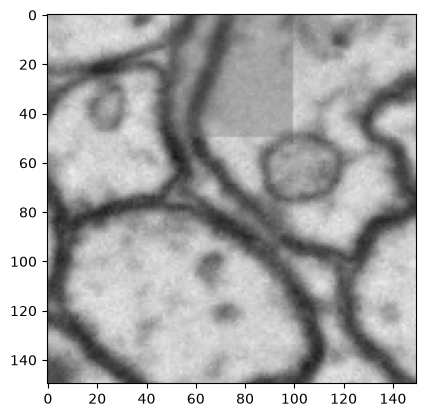

In [33]:
np.array(stitched_volume).shape
plt.imshow(stitched_volume[0], cmap='gray', vmin=0, vmax=1)

  window overlaps blocks [(0, 1, 1), (1, 1, 1)] (2 resident in cache)
Gaussians inside the 32^3 window at (62, 75, 75): 13,876 (of 100,000 loaded from overlapping blocks)


MIP-splat render [real CUDA splat_mip kernel (rotated Gaussians, no reconstruction)]: 1 frames @ 256x256  -> avg 577.6 ms/frame (1.73 FPS)  [min 577.6 / max 577.6 ms]
Cube center: (62, 75, 75)
Gaussians inside cube: 13,876
One splat-MIP view: 588.8 ms -> 1.73 FPS


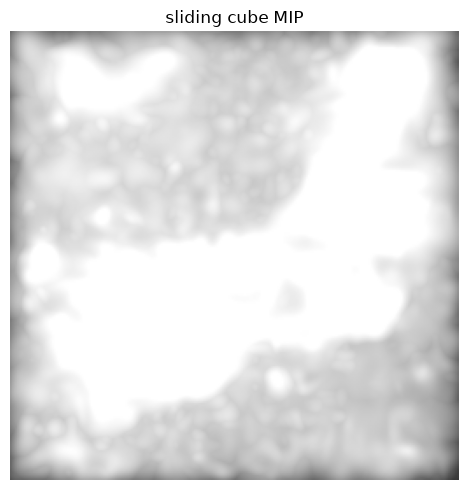

In [20]:
%matplotlib inline
# Test the sliding-cube render directly.
# The camera is at the center of the 32x32x32 cube, and only Gaussians whose
# means lie inside that cube are rendered with the fused CUDA splat_mip kernel.
import time
import importlib
import scripts.render_scripts.sliding_window_camera as swc
swc = importlib.reload(swc)

center_zyx = (62, 75, 75)
if device.type == 'cuda':
    torch.cuda.synchronize()
t0 = time.perf_counter()
frames, local_vol, metrics = swc.render_sliding_block(
    block_cache, stitched_volume.shape, center_zyx, block_size=32,
    n_frames=1, fov=90.0, img_size=256,
    method='cuda_splat',
)
if device.type == 'cuda':
    torch.cuda.synchronize()
elapsed_s = time.perf_counter() - t0

print(f'Cube center: {center_zyx}')
print(f'Gaussians inside cube: {metrics["n_gaussians"]:,}')
print(f'One splat-MIP view: {elapsed_s * 1000:.1f} ms -> {metrics["fps"]:.2f} FPS')

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(frames[0], cmap='gray', vmin=0, vmax=1)
ax.set_title('sliding cube MIP')
ax.axis('off')
plt.tight_layout()
plt.show()


  window overlaps blocks [(0, 1, 1), (1, 1, 1)] (2 resident in cache)


  window overlaps blocks [(0, 1, 1), (1, 1, 1)] (2 resident in cache)
Gaussians inside the 32^3 window at (62, 75, 75): 13,876 (of 100,000 loaded from overlapping blocks)
MIP-splat render [real CUDA splat_mip kernel (rotated Gaussians, no reconstruction)]: 1 frames @ 256x256  -> avg 578.1 ms/frame (1.73 FPS)  [min 578.1 / max 578.1 ms]
GT DVR/MIP   : 256x256 view in 781.3 ms
Sliding cube : 256x256 view in 579.9 ms -> 1.73 FPS
Sliding cube Gaussians inside cube: 13,876


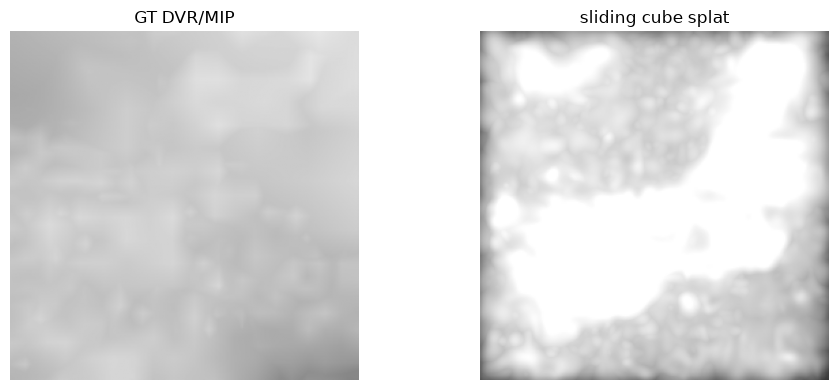

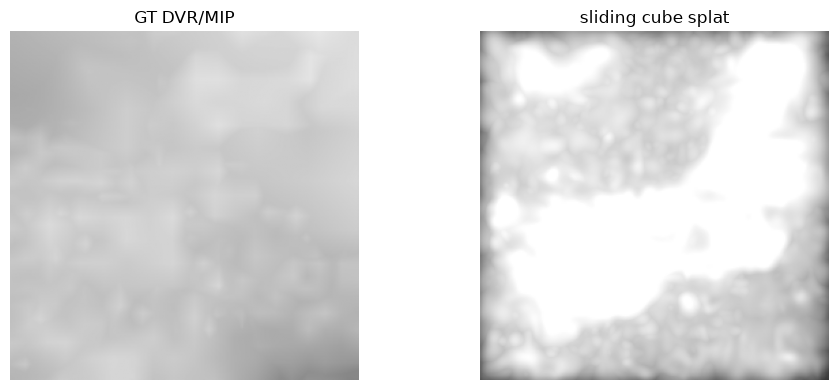

In [24]:
%matplotlib inline
# Compare the sliding-cube splat MIP against the GT DVR/MIP render.
# Both views use the same 32^3 cube and the same 256x256 image size.
import time
import importlib
import scripts.render_scripts.sliding_window_camera as swc
swc = importlib.reload(swc)
from scripts.render_scripts.render_camera import render_frame

center_zyx = (62, 75, 75)
block_size = 32

# Build the GT cube from the same sliding window, then render it with the DVR/MIP camera.
windowed_gc = block_cache.get_gaussians_for_window(center_zyx, block_size)
local_gc, bounds = swc.filter_gaussians_in_block(windowed_gc, center_zyx, block_size, stitched_volume.shape)
gt_vol = swc.reconstruct_local_cube(local_gc, bounds, block_size, device)

if device.type == 'cuda':
    torch.cuda.synchronize()
t0 = time.perf_counter()
gt_frame = render_frame(gt_vol, azimuth_deg=0.0, elev_deg=0.0, fov_deg=90.0, img_h=256, img_w=256, n_steps=128)
if device.type == 'cuda':
    torch.cuda.synchronize()
gt_ms = (time.perf_counter() - t0) * 1000

# Render the same cube with the splat kernel.
if device.type == 'cuda':
    torch.cuda.synchronize()
t0 = time.perf_counter()
frames, local_vol, metrics = swc.render_sliding_block(
    block_cache, stitched_volume.shape, center_zyx, block_size=block_size,
    n_frames=1, fov=90.0, img_size=256,
    method='cuda_splat',
)
if device.type == 'cuda':
    torch.cuda.synchronize()
slide_ms = (time.perf_counter() - t0) * 1000
slide_fps = metrics['fps']

print(f'GT DVR/MIP   : 256x256 view in {gt_ms:.1f} ms')
print(f'Sliding cube : 256x256 view in {slide_ms:.1f} ms -> {slide_fps:.2f} FPS')
print(f'Sliding cube Gaussians inside cube: {metrics["n_gaussians"]:,}')

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(gt_frame, cmap='gray', vmin=0, vmax=1)
axs[0].set_title('GT DVR/MIP')
axs[0].axis('off')
axs[1].imshow(frames[0], cmap='gray', vmin=0, vmax=1)
axs[1].set_title('sliding cube splat')
axs[1].axis('off')
plt.tight_layout()
plt.show()


  window overlaps blocks [(0, 1, 1), (1, 1, 1)] (2 resident in cache)


Direct CUDA eval kernel inside sliding cube: 4.2 ms for 256x256
GT DVR/MIP inside same cube: 897.9 ms for 256x256
Gaussians inside cube: 13,876


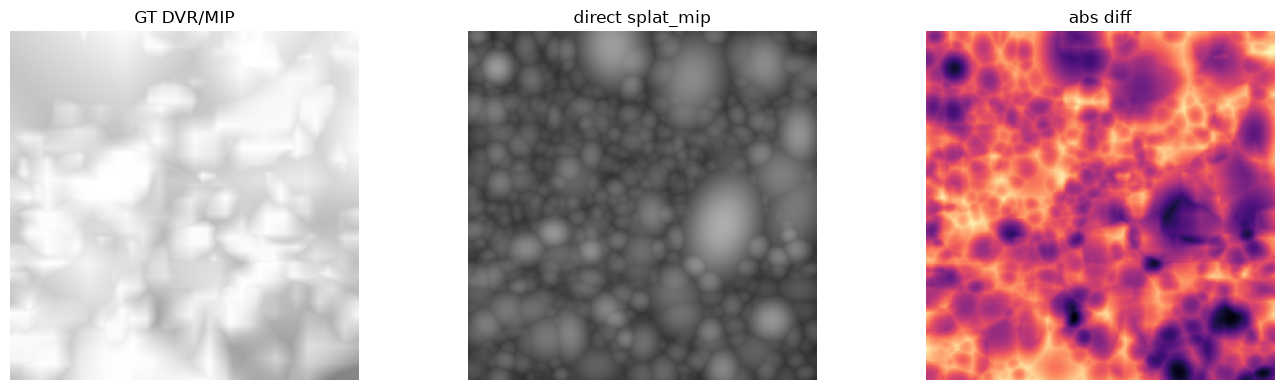

In [9]:
%matplotlib inline
# Directly run the CUDA eval kernel inside the sliding cube, then compare it
# against the GT DVR/MIP render from the same cube. The splat result is a
# blob-like Gaussian projection; the GT view is what carries the volume detail.
import time
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt

import scripts.render_scripts.sliding_window_camera as swc
swc = importlib.reload(swc)
from scripts.render_scripts.sliding_window_camera import BlockGaussianCache
from scripts.render_scripts.render_camera import render_frame
from scripts._3dgs._3dgs import _load_eval_kernel

base_z, base_y, base_x = 0, 1, 6
center_zyx = (62, 75, 75)
block_size = 32
img_size = 256
azimuth_deg = 0.0

device = sliding_cache.device if 'sliding_cache' in globals() else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sliding_cache = BlockGaussianCache(
    blocks_dir='../models_smoke',
    base_zyx=(base_z, base_y, base_x),
    grid_n=3,
    global_shape=stitched_volume.shape,
    block_size=50,
    block_shape_fn=lambda dz, dy, dx: (25 if dz == 2 else 50, 50, 50),
)
windowed_gc = sliding_cache.get_gaussians_for_window(center_zyx, block_size)
local_gc, bounds = swc.filter_gaussians_in_block(windowed_gc, center_zyx, block_size, stitched_volume.shape)
means, log_s = swc.recenter_and_rescale(local_gc, bounds)

# Rotate the world by -azimuth so the fixed Z-projection matches the camera yaw.
theta = torch.tensor(-np.radians(azimuth_deg), device=means.device, dtype=means.dtype)
c, s = torch.cos(theta), torch.sin(theta)
R_y = torch.tensor([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]], device=means.device, dtype=means.dtype)
means_rot = means @ R_y.T
q_delta = torch.stack([
    torch.cos(theta / 2),
    torch.zeros((), device=means.device, dtype=means.dtype),
    torch.sin(theta / 2),
    torch.zeros((), device=means.device, dtype=means.dtype),
]).unsqueeze(0).expand(means.shape[0], 4)
quats_rot = swc.quat_multiply(q_delta, local_gc.quats)

kernel = _load_eval_kernel()
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
flat = kernel.splat_mip(
    means_rot.contiguous(),
    log_s.contiguous(),
    quats_rot.contiguous(),
    local_gc.inten.contiguous(),
    -1.0, 1.0, -1.0, 1.0, -1.0, 1.0,
    img_size, img_size, 32, 0,
    float(local_gc.scale_min), float(local_gc.mahal_clamp),
)
if torch.cuda.is_available():
    torch.cuda.synchronize()
splat_ms = (time.perf_counter() - t0) * 1000
splat_frame = flat.reshape(img_size, img_size).clamp(0, 1).cpu().numpy().astype(np.float32)

# Build the GT cube from the same sliding window, then render it with DVR/MIP.
gt_vol = swc.reconstruct_local_cube(local_gc, bounds, block_size, sliding_cache.device)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t0 = time.perf_counter()
gt_frame = render_frame(gt_vol, azimuth_deg=0.0, elev_deg=0.0, fov_deg=90.0, img_h=img_size, img_w=img_size, n_steps=128)
if torch.cuda.is_available():
    torch.cuda.synchronize()
gt_ms = (time.perf_counter() - t0) * 1000

print(f'Direct CUDA eval kernel inside sliding cube: {splat_ms:.1f} ms for {img_size}x{img_size}')
print(f'GT DVR/MIP inside same cube: {gt_ms:.1f} ms for {img_size}x{img_size}')
print(f'Gaussians inside cube: {local_gc.means.shape[0]:,}')

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].imshow(gt_frame, cmap='gray', vmin=0, vmax=1)
axs[0].set_title('GT DVR/MIP')
axs[0].axis('off')
axs[1].imshow(splat_frame, cmap='gray', vmin=0, vmax=1)
axs[1].set_title('direct splat_mip')
axs[1].axis('off')
axs[2].imshow(np.abs(gt_frame - splat_frame), cmap='magma')
axs[2].set_title('abs diff')
axs[2].axis('off')
plt.tight_layout()
plt.show()
